In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve

In [53]:
import sys
sys.path.append("../src")
from preprocessing import prepare_data
from training import train_models

pd.set_option("display.float_format", "{:.2f}".format)

RANDOM_SEED = 0

## Get preprocessed data and models

In [54]:
X_train_A, X_test_A, X_train_B, X_test_B, y_train, y_test, scaler, ohe = prepare_data()
lr_A, lasso_A, ridge_A, en_A = train_models(X_train_A, y_train)
lr_B, lasso_B, ridge_B, en_B = train_models(X_train_B, y_train)

/Users/antonioponti/miniconda3/envs/mlenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.725e+12, tolerance: 1.057e+11
  model = cd_fast.enet_coordinate_descent(
/Users/antonioponti/miniconda3/envs/mlenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.700e+13, tolerance: 1.057e+11
  model = cd_fast.enet_coordinate_descent(
/Users/antonioponti/miniconda3/envs/mlenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

## Evaluation functions

### First we define a function to calculate different metrics for each model

In [57]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mean_price = y_test.mean()
    
    return {
        "R2": r2_score(y_test, y_pred),
        "MSE": mse,
        "MAE": mae,
        "MAE %": (mae / mean_price) * 100,
        "RMSE %": (rmse / mean_price) * 100,
    }

### Then a function for Cross Validation using K-Fold CV

In [69]:
def cv_evaluate(model, X, y, k=5):
    cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    return scores.mean(), scores.std()

## Coefficents extraction function

In [59]:
def get_coefficients(model, feature_names):
    coefs = model.coef_
    df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefs
    })
    return df.sort_values(by="Coefficient", ascending=False)

## Evaulation Data

In [60]:
# Build table rows
rows = []

# ===== DATASET A =====
rows.append([
    "A", "LinearRegression", None, None,
    *evaluate_model(lr_A, X_test_A, y_test).values()
])

rows.append([
    "A", "Ridge", ridge_A.alpha, None,
    *evaluate_model(ridge_A, X_test_A, y_test).values()
])

rows.append([
    "A", "Lasso", lasso_A.alpha, None,
    *evaluate_model(lasso_A, X_test_A, y_test).values()
])

rows.append([
    "A", "ElasticNet", en_A.alpha, en_A.l1_ratio,
    *evaluate_model(en_A, X_test_A, y_test).values()
])

# ===== DATASET B =====
rows.append([
    "B", "LinearRegression", None, None,
    *evaluate_model(lr_B, X_test_B, y_test).values()
])

rows.append([
    "B", "Ridge", ridge_B.alpha, None,
    *evaluate_model(ridge_B, X_test_B, y_test).values()
])

rows.append([
    "B", "Lasso", lasso_B.alpha, None,
    *evaluate_model(lasso_B, X_test_B, y_test).values()
])

rows.append([
    "B", "ElasticNet", en_B.alpha, en_B.l1_ratio,
    *evaluate_model(en_B, X_test_B, y_test).values()
])

# Build DataFrame
eval_df = pd.DataFrame(rows, columns=[
    "Dataset", "Model", "alpha", "l1_ratio", "R2", "MSE", "MAE", "MAE %", "RMSE %"
])

eval_df

,Dataset,Model,alpha,l1_ratio,R2,MSE,MAE,MAE %,RMSE %
0,A,LinearRegression,NaN,NaN,0.72,961887082256.53,736637.06,15.46,20.59
1,A,Ridge,10.00,NaN,0.74,905432996861.38,715489.66,15.02,19.98
2,A,Lasso,100.00,NaN,0.72,961441942074.59,736413.85,15.46,20.58
3,A,ElasticNet,0.10,0.50,0.74,896687944874.78,713635.22,14.98,19.88
4,B,LinearRegression,NaN,NaN,0.72,955428862101.25,731779.35,15.36,20.52
5,B,Ridge,10.00,NaN,0.74,902578966386.93,711680.01,14.94,19.94
6,B,Lasso,100.00,NaN,0.72,955002414551.84,731573.67,15.36,20.52
7,B,ElasticNet,0.10,0.30,0.74,896915746282.94,711339.16,14.93,19.88


## Metric Analysis

Overall, the models achieve **R² values between 0.72 and 0.74** on the test set. Given the limited number of features and the intrinsic non-linearity of real-estate prices, these values are consistent with what can be reasonably expected from linear models.

In terms of error magnitude, the **Mean Absolute Error (MAE)** is approximately **700k**, which corresponds to an average **MAE between 15% and 15.5%** of the mean house price. The **RMSE** is around **20%** of the mean price. Although the absolute error may appear large in absolute terms, expressing it as a percentage highlights that the models are, on average, within roughly **±15%** of the true price, which is acceptable for this type of problem and model family.

Comparing the different algorithms, **Ridge** and **ElasticNet** systematically outperform both **Linear Regression** and **Lasso**, achieving the **highest R²** and the **lowest MSE, MAE, MAE% and RMSE%** on both Dataset A and Dataset B. The best overall performances are obtained by **ElasticNet**, with MAE% ≈ **15.0%** on Dataset A and **14.9%** on Dataset B.

Finally, the performance difference between **Dataset A** (numeric `furnishingstatus`) and **Dataset B** (one-hot encoded `furnishingstatus`) is minimal. This suggests that the furnishing status has **limited predictive power** in this dataset, and that the choice of encoding does not substantially change the overall accuracy of the models, even though the one-hot representation is more interpretable.

In [61]:
def coef_table(models_dict, feature_names):
    coef_data = {}

    for name, model in models_dict.items():
        coefs = model.coef_
        # sanity check
        if len(coefs) != len(feature_names):
            raise ValueError(f"Model {name} has {len(coefs)} coefficients, "
                             f"but there are {len(feature_names)} features.")
        coef_data[name] = coefs

    df = pd.DataFrame(coef_data, index=feature_names)
    # optional: sort by one model or by average absolute effect
    df["avg_abs"] = df.abs().mean(axis=1)
    df = df.sort_values(by="avg_abs", ascending=False).drop(columns=["avg_abs"])
    return df

In [113]:
features_A = X_train_A.columns.tolist()

models_A = {
    "Linear": lr_A,
    "Ridge": ridge_A,
    "Lasso": lasso_A,
    "ElasticNet": en_A,
}

coef_A = coef_table(models_A, features_A)
coef_A

,Linear,Ridge,Lasso,ElasticNet
hotwaterheating,1262664.64,725899.75,1259907.75,517291.98
airconditioning,932687.20,792270.53,932064.83,711145.48
prefarea,702038.39,618942.50,701649.34,564764.94
area,491162.13,501669.10,491275.54,507039.87
bathrooms,460222.86,464167.53,460263.03,462885.97
mainroad,508056.85,419586.23,507254.02,367630.12
guestroom,419245.01,376285.19,418754.30,347752.25
stories,374035.90,381702.86,374039.79,383028.77
basement,357283.11,347267.69,357085.39,334991.36
parking,202056.71,221921.97,202115.02,229984.99


## Coefficient Analysis – Dataset A

Across all four linear models (Linear Regression, Ridge, Lasso, ElasticNet), the ranking of feature importance is highly consistent, confirming the stability of the learned relationships. Features related to **hot water heating**, **air conditioning**, **preferred area**, **total area**, and **number of bathrooms** consistently receive the largest coefficients, indicating they are the dominant drivers of housing price in this dataset.

Regularization (Ridge and ElasticNet) shrinks coefficients by a moderate amount but does not substantially alter their relative magnitudes or signs. Lasso does not zero-out any coefficient, suggesting that all features contribute meaningfully to the target.

The `furnishingstatus` feature, encoded as a numeric value in Dataset A, receives a relatively small coefficient and may not represent meaningful ordinal information. This motivates the comparison with Dataset B, where `furnishingstatus` is one-hot encoded to allow a more expressive and interpretable treatment of this categorical variable.

In [114]:
features_B = X_train_B.columns.tolist()

models_B = {
    "Linear": lr_B,
    "Ridge": ridge_B,
    "Lasso": lasso_B,
    "ElasticNet": en_B,
}

coef_B = coef_table(models_B, features_B)
coef_B

,Linear,Ridge,Lasso,ElasticNet
hotwaterheating,1248046.21,717906.86,1245338.02,410017.48
airconditioning,908687.59,770509.41,908113.57,640619.55
prefarea,694592.19,611611.99,694233.54,521372.19
area,486808.92,496719.32,486901.47,504094.28
bathrooms,458146.39,461965.85,458190.44,458324.19
mainroad,478260.79,394773.06,477484.96,316235.84
stories,367910.08,374607.55,367916.67,374642.71
guestroom,385176.11,346655.93,384731.39,304565.16
basement,353539.58,342323.40,353329.78,318504.84
furnishingstatus_0,-274779.16,-269212.00,-378395.64,-254892.49


## Coefficient Analysis – Dataset B

In Dataset B, the `furnishingstatus` feature is represented through three dummy variables
(`furnishingstatus_0`, `furnishingstatus_1`, `furnishingstatus_2`) corresponding to the
unfurnished, semi‐furnished, and fully‐furnished categories. Since all three dummy
variables are included, they are perfectly collinear (`d0 + d1 + d2 = 1`), which makes
their coefficients non-identifiable and therefore unstable.

This behavior is clearly visible in the results: the coefficients of the furnishingstatus
dummies vary substantially across models, with Lasso even pushing one of them to zero.
Ridge and ElasticNet distribute the effect more smoothly, but the individual magnitudes
and signs still fluctuate due to the intrinsic redundancy between the dummy variables.

Despite this instability, the overall trend remains consistent: semi-furnished and fully
furnished homes tend to receive positive adjustments (≈ +80k to +180k), while
unfurnished homes receive negative adjustments (≈ −250k). This reflects the expected
premium associated with higher furnishing levels.

These results further confirm that dummy variables should ideally be encoded with
`drop="first"` to avoid perfect multicollinearity and to obtain interpretable
coefficients. Dataset B still performs similarly to Dataset A in terms of predictive
accuracy, but its furnishingstatus coefficients are less reliable to interpret due to
this redundancy.

# DataSet Analysis

## Sanity Check

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


### Data Info Analysis
The output shows that the dataset contains 545 rows for 13 features. 
All the 13 features have 545 non-null values. This indicates that there are no missing entries in any column, this means there is no need for dropping or imputation of any row or columns due to missing values.

## Correlation Matrix

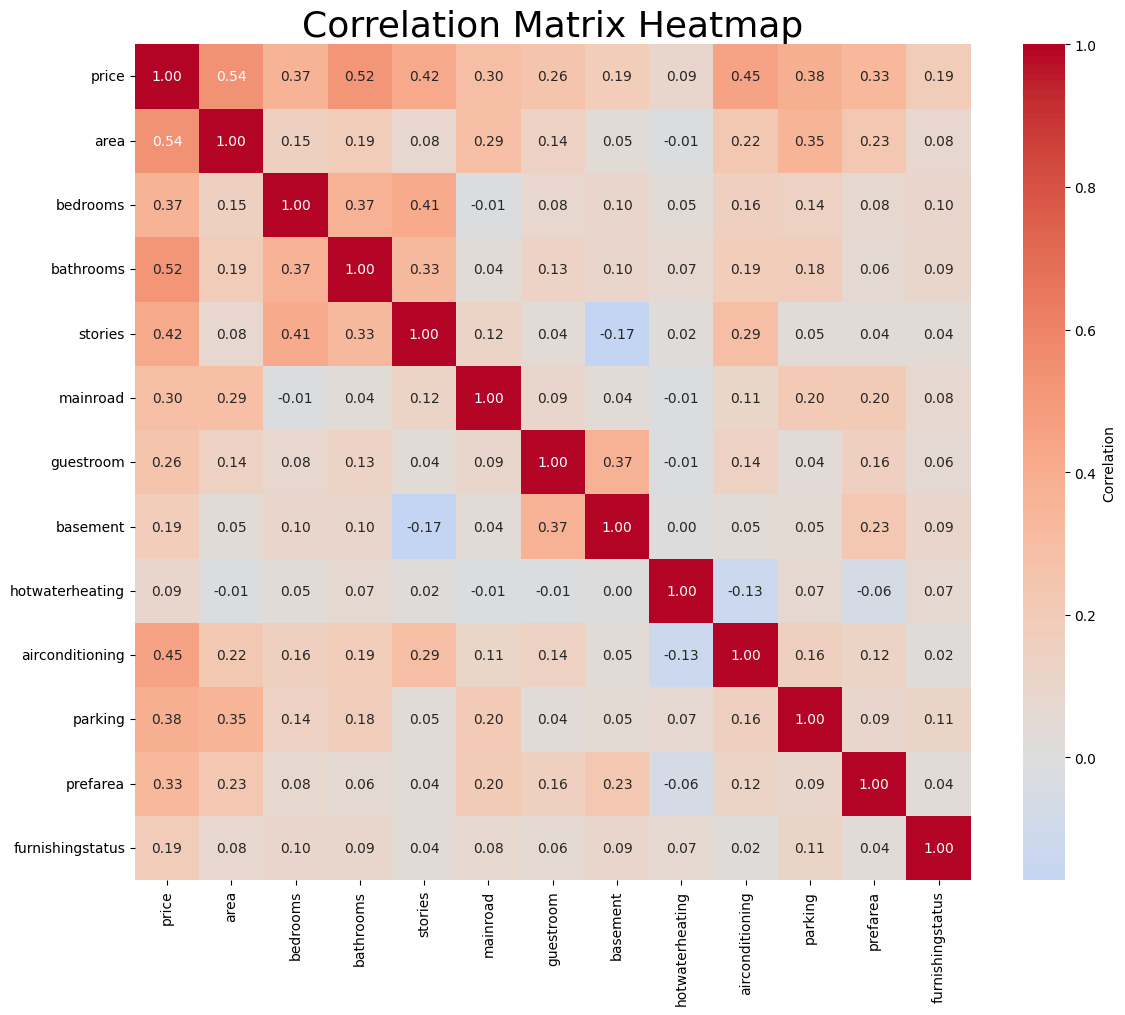

In [65]:
# Calculate correlation matrix
correlation_matrix = data.corr()
# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix Heatmap', fontsize=26)
plt.tight_layout()
plt.show()

### Correlation Matrix Analysis

The correlation matrix shows that none of the features are strongly correlated with each other (no pair exceeds ≈ 0.4). This indicates the absence of multicollinearity. As a result, the linear regression model should remain numerically stable and well-behaved without the need to drop features. 

The moderate correlations each feature has with the target (e.g., area, bathrooms, airconditioning) suggest that each variable contributes independently to explaining the price, allowing us to retain the full feature set in the model.

## Feature Analysis

In [66]:
data.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.86,0.18,0.35,0.05,0.32,0.69,0.23,1.09
std,1870439.62,2170.14,0.74,0.50,0.87,0.35,0.38,0.48,0.21,0.47,0.86,0.42,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00,0.00,1.00,0.00,1.00,1.00,0.00,2.00
max,13300000.00,16200.00,6.00,4.00,4.00,1.00,1.00,1.00,1.00,1.00,3.00,1.00,2.00


In [67]:
data.agg(["max", "min"])

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
max,13300000,16200,6,4,4,1,1,1,1,1,3,1,2
min,1750000,1650,1,1,1,0,0,0,0,0,0,0,0


### Feature Scale Analysis

From the summary statistics we can see that most features have small integer ranges, while `area` is the only one that covers a much larger range of values. When one feature has a scale much bigger than the others, it can end up influencing the optimization of a Linear Regression model more than it should. Therefore is safer to scale all numeric features (`area`, `bedrooms`, `bathrooms`, `stories`, `parking`) so that they contribute more evenly during training. 
The binary 0/1 features don’t need scaling.

### Treatment of the `furnishingstatus` Feature

The `furnishingstatus` column is encoded as 0, 1, and 2, but these numbers don’t really represent a linear or proportional relationship. The effect that furniture has on the final price depends on the market and isn’t necessarily “twice as important” when going from 1 to 2 compared to going from 0 to 1. This is also reflected in its low correlation with the target (around 0.19). For this reason, it may be better to treat it as a categorical variable and apply One-Hot Encoding. 
To verify this thesis, we will train two separate models: one using the numeric encoding (0, 1, 2) and one using One-Hot Encoding. This will allow us to directly compare their performance and see which approach works best for this dataset.

## Cross Validation

In [72]:
for name, model in models_A.items():
    cv_mean, cv_std = cv_evaluate(model, X_train_A, y_train)
    print(f"{name}: CV R² = {cv_mean:.3f} ± {cv_std:.3f}")

Linear: CV R² = 0.623 ± 0.053
Ridge: CV R² = 0.624 ± 0.047
Lasso: CV R² = 0.623 ± 0.053
ElasticNet: CV R² = 0.622 ± 0.047


In [73]:
for name, model in models_B.items():
    cv_mean, cv_std = cv_evaluate(model, X_train_B, y_train)
    print(f"{name}: CV R² = {cv_mean:.3f} ± {cv_std:.3f}")

Linear: CV R² = 0.625 ± 0.053
Ridge: CV R² = 0.625 ± 0.049
Lasso: CV R² = 0.625 ± 0.053
ElasticNet: CV R² = 0.622 ± 0.050


### Cross Validation Analysis
Cross-validation yields R² values of approximately 0.62–0.63 across all models and 
both dataset representations. These values are lower than the final test-set R² 
(≈0.72–0.74), which is expected because each CV fold trains on only 80% of the data, 
resulting in slightly weaker models. The small variation between folds (std ≈ 0.05) 
indicates stable performance across different train/validation splits.

Interestingly, all linear models achieve almost identical CV performance, suggesting 
that the dataset does not significantly benefit from L1/L2 regularization. This is 
consistent with earlier observations: the features are not highly collinear, none of 
them are irrelevant, and the true underlying relationships in house pricing are likely 
nonlinear and only partially captured by the model.

# Results Visualization

### Let's forst define a function to plot and show the model learning curve

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, KFold

def plot_learning_curves_grid(models_dict, X, y, cv_splits=5, title_prefix="Dataset A"):
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=0)
    train_sizes = np.linspace(0.1, 1.0, 10)

    # Prepare 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, (name, model) in enumerate(models_dict.items()):
        
        # Compute learning curve
        ts, train_scores, val_scores = learning_curve(
            estimator=model,
            X=X,
            y=y,
            cv=cv,
            scoring="r2",
            train_sizes=train_sizes,
            n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)

        ax = axes[idx]

        # Plot training scores
        ax.plot(ts, train_mean, label="Training Score", color="blue")
        ax.fill_between(ts, train_mean - train_std, train_mean + train_std,
                        alpha=0.2, color="blue")

        # Plot validation scores
        ax.plot(ts, val_mean, label="Validation Score", color="orange")
        ax.fill_between(ts, val_mean - val_std, val_mean + val_std,
                        alpha=0.2, color="orange")

        ax.set_title(f"{name} – {title_prefix}")
        ax.set_xlabel("Training Set Size")
        ax.set_ylabel("R² Score")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

## Learning Curves for DataSet A

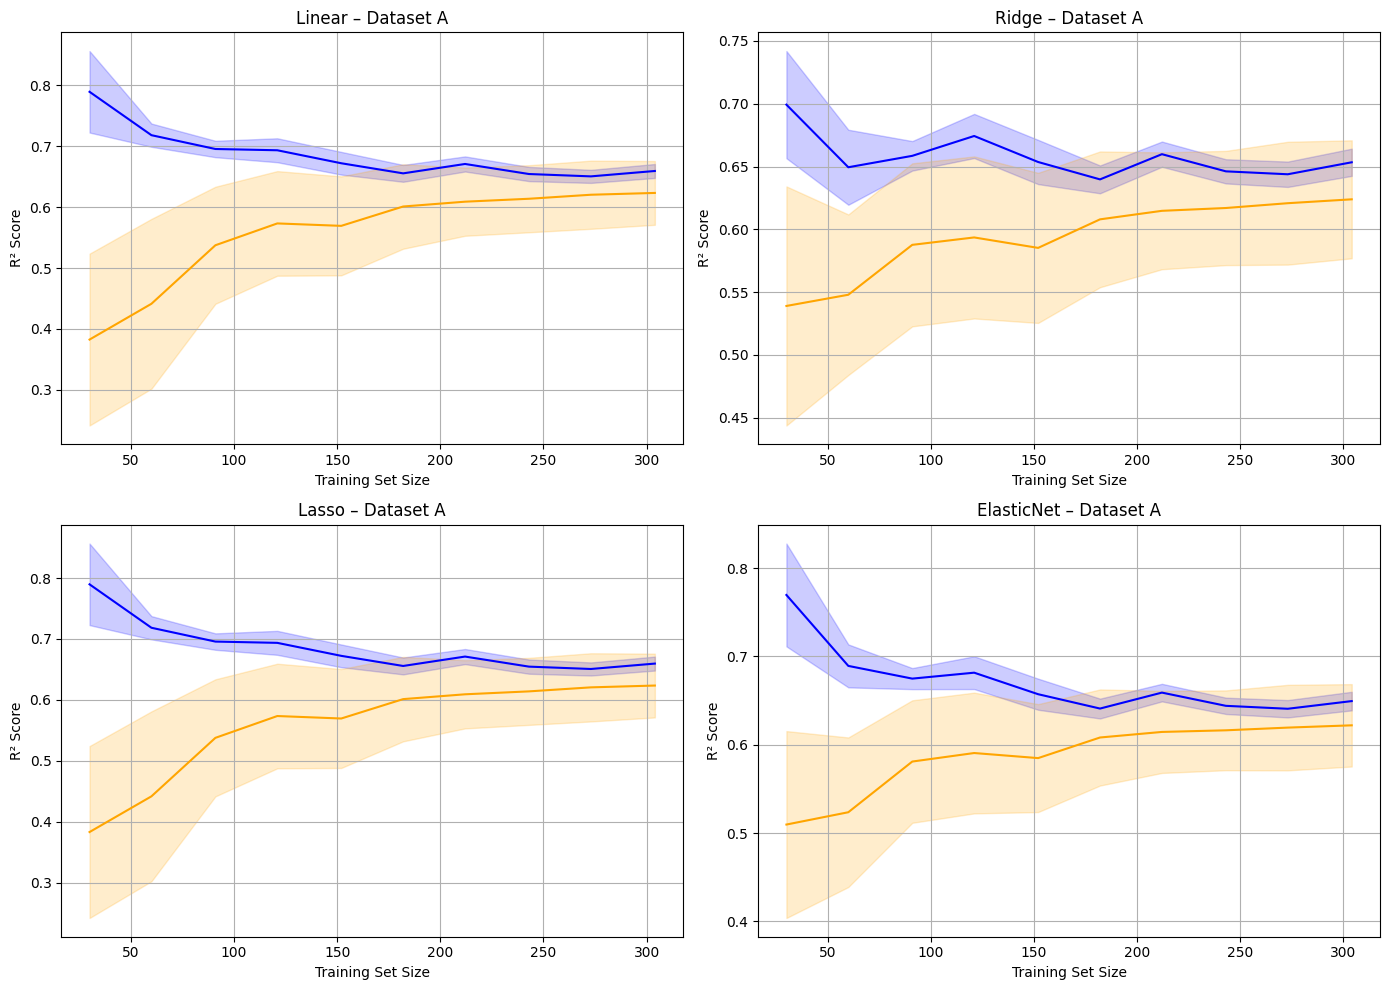

In [ ]:
plot_learning_curves_grid(models_A, X_train_A, y_train, 5, "Dataset A")

### Learning Curve Analysis – Dataset A

The learning curves for all four models (Linear Regression, Ridge, Lasso, ElasticNet)
exhibit very similar behavior. The training R² starts high on small subsets of data and
gradually decreases as the training size increases, while the validation R² increases
steadily. Both curves converge around values close to 0.65, indicating that the models
are not overfitting.

Regularization (Ridge, Lasso, ElasticNet) slightly stabilizes the curves, reducing the
variance across different training subsets, but it does not produce a significant
aimprovement in accuracy. This suggests that the dataset does not contain irrelevant
features and that most of the remaining error is due to the intrinsic limitations of
linear models when applied to real-estate pricing, a problem known to have nonlinear
relationships.

## Learning Curves for Dataset B

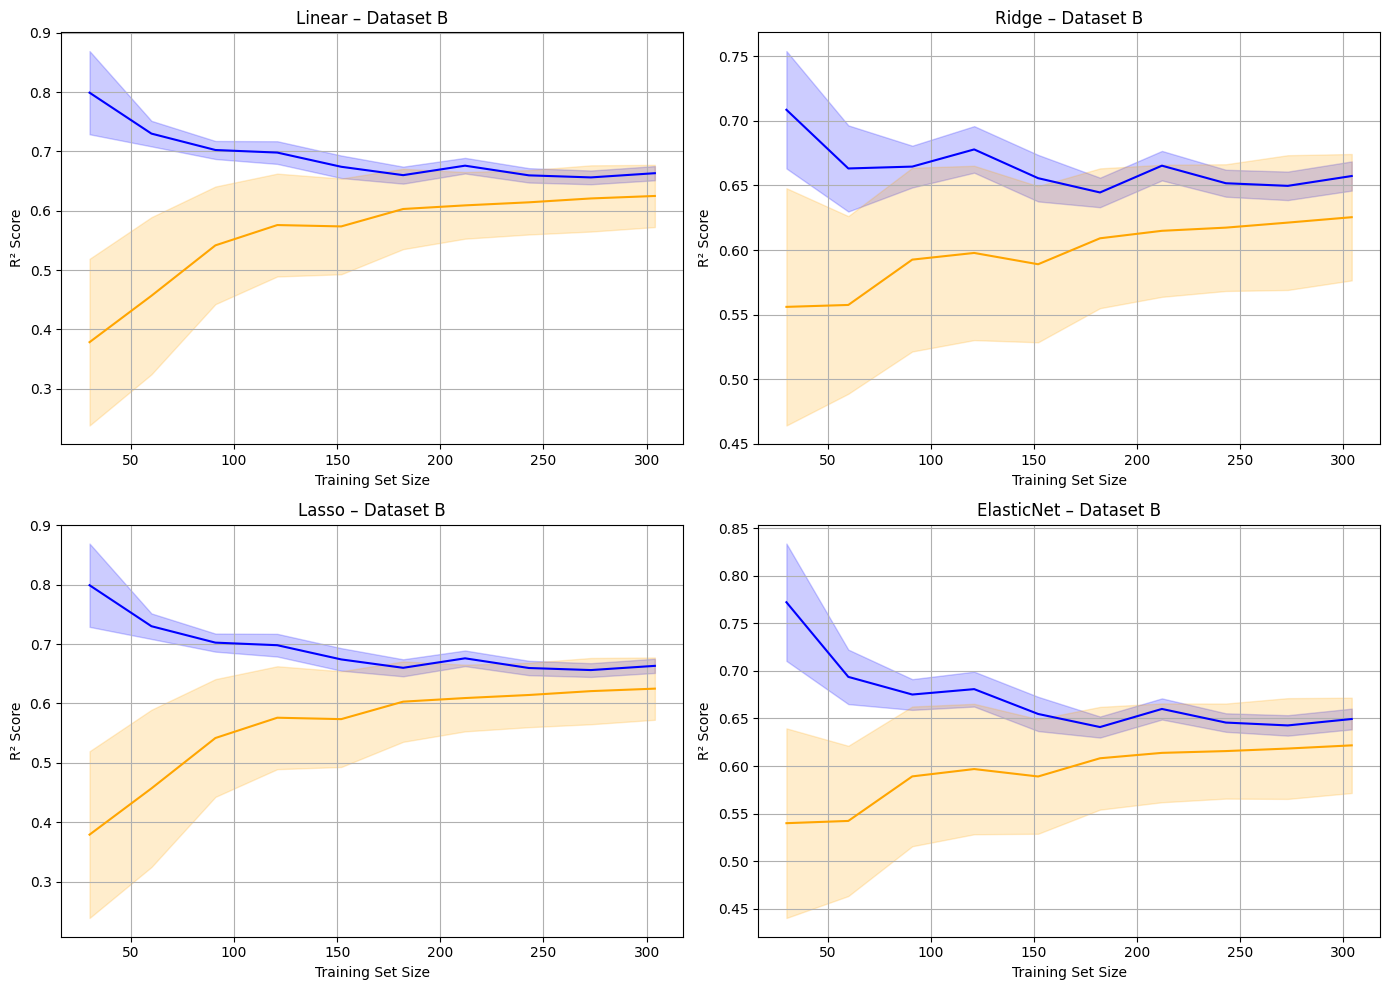

In [116]:
plot_learning_curves_grid(models_B, X_train_B, y_train, 5, "Dataset B")

## Residuals

### Function for Residual Analysis visualization

In [103]:
def plot_residuals(model, X_test, y_test, title_prefix="Residual Analysis"):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Residuals vs Predicted ---
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_xlabel("Predicted Values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"{title_prefix} – Residuals vs Predicted")
    axes[0].grid(True)

    # --- Residual Distribution ---
    sns.histplot(residuals, bins=30, kde=True, color="purple", alpha=0.6, ax=axes[1])
    axes[1].set_xlabel("Residuals")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"{title_prefix} – Distribution of Residuals")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

### Simple Linear Regression Residuals

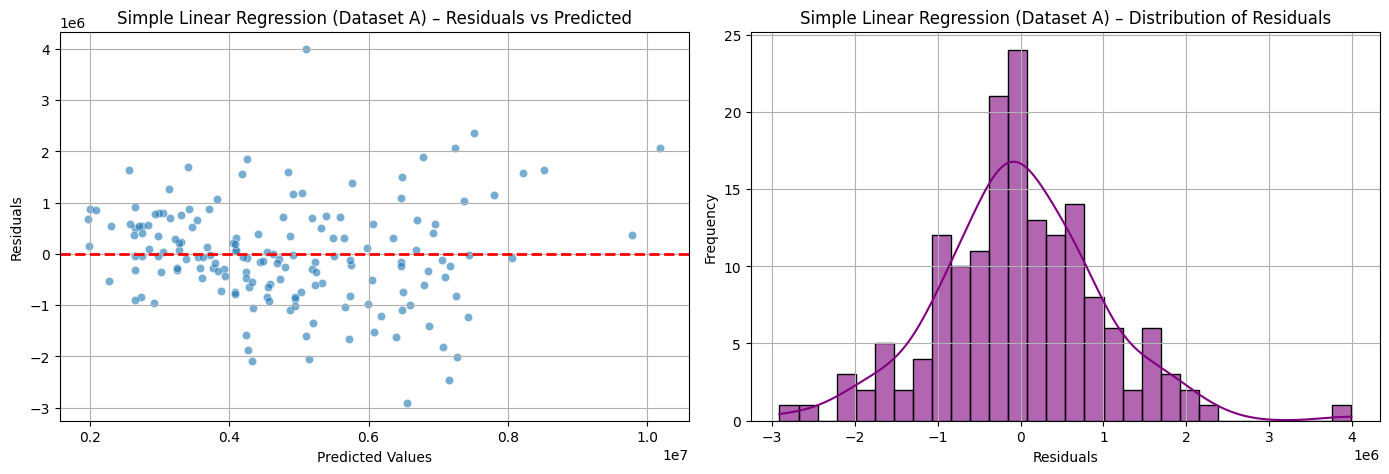

In [ ]:
plot_residuals(lr_A, X_test_A, y_test, title_prefix="Simple Linear Regression (Dataset A)")

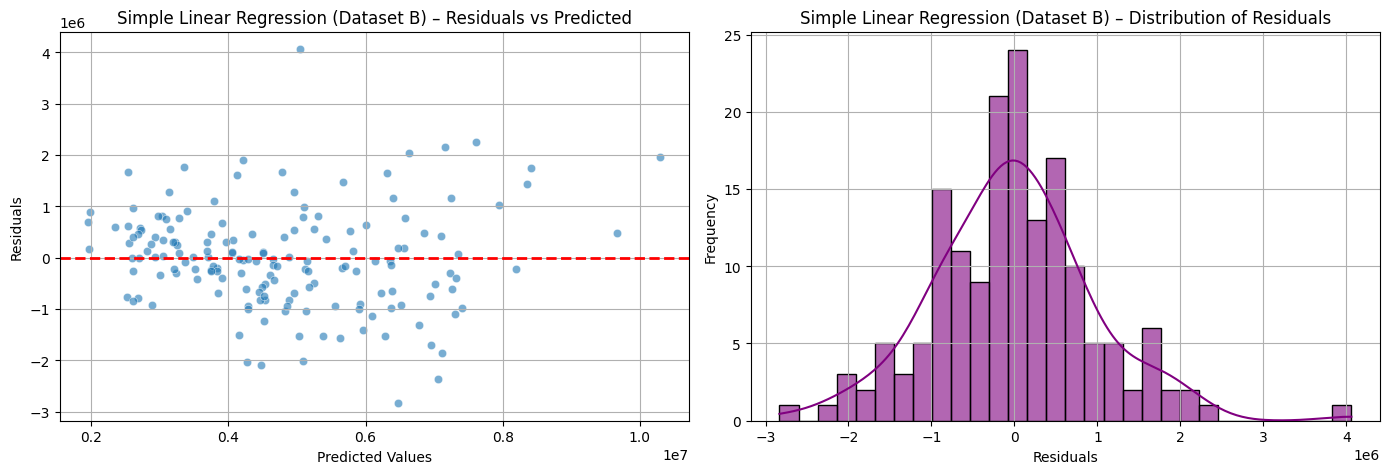

In [105]:
plot_residuals(lr_B, X_test_B, y_test, title_prefix="Simple Linear Regression (Dataset B)")

### Lasso Residuals

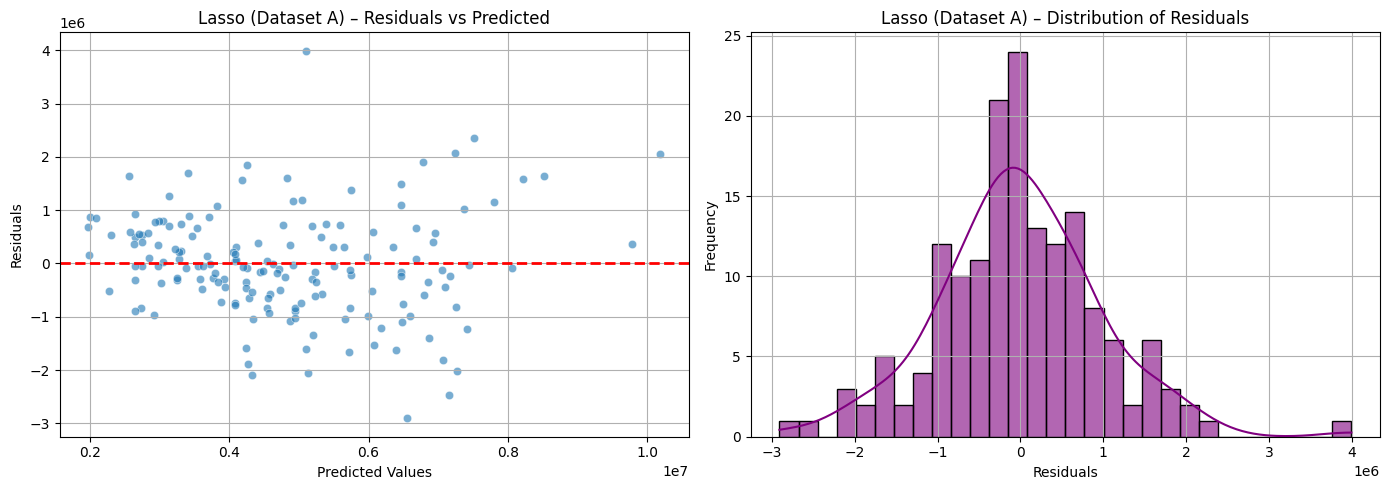

In [106]:
plot_residuals(lasso_A, X_test_A, y_test, title_prefix="Lasso (Dataset A)")

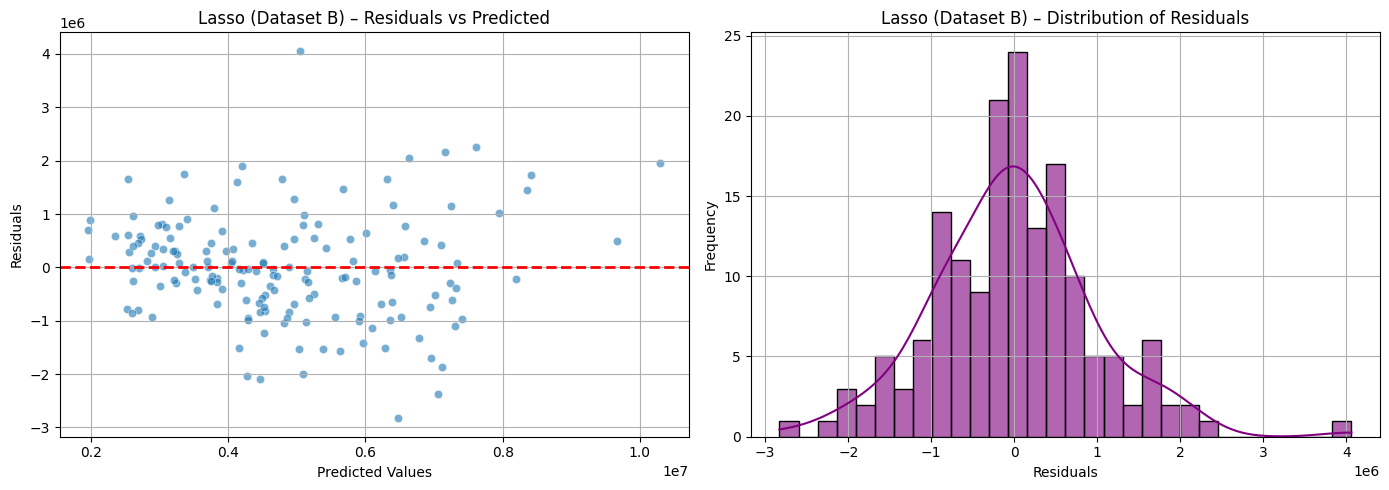

In [107]:
plot_residuals(lasso_B, X_test_B, y_test, title_prefix="Lasso (Dataset B)")

### Ridge Residuals

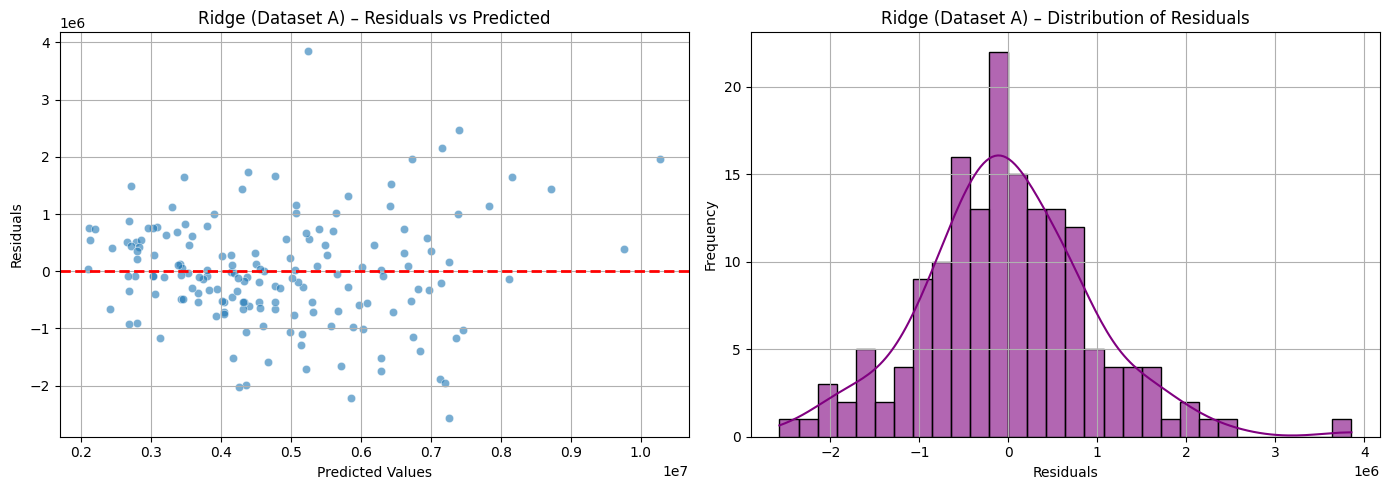

In [ ]:
plot_residuals(ridge_A, X_test_A, y_test, title_prefix="Ridge (Dataset A)")

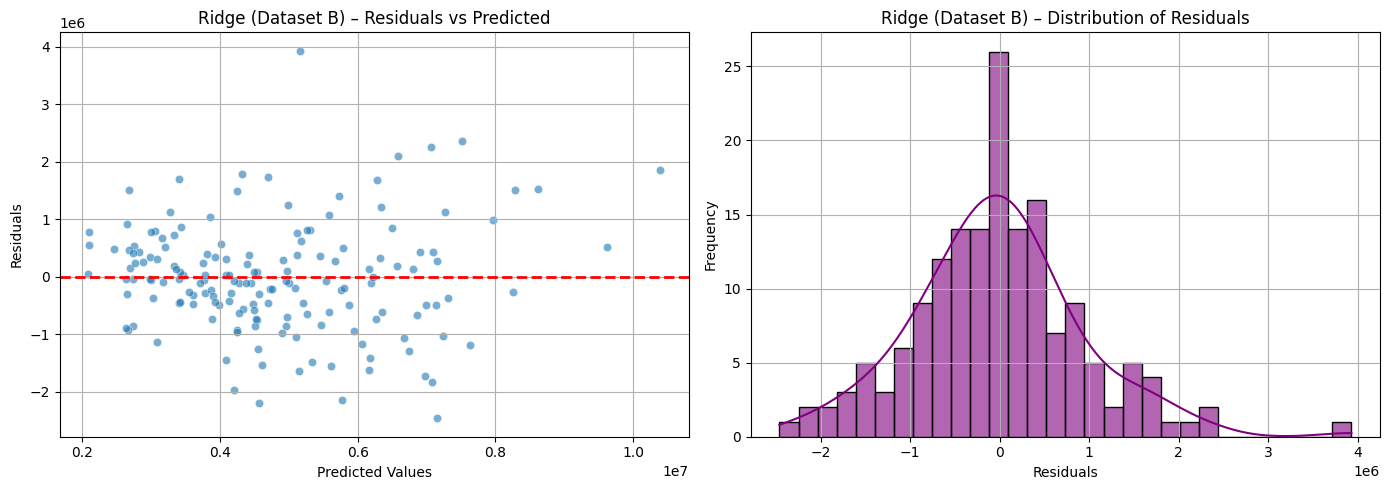

In [109]:
plot_residuals(ridge_B, X_test_B, y_test, title_prefix="Ridge (Dataset B)")

### Elastic Net Residuals

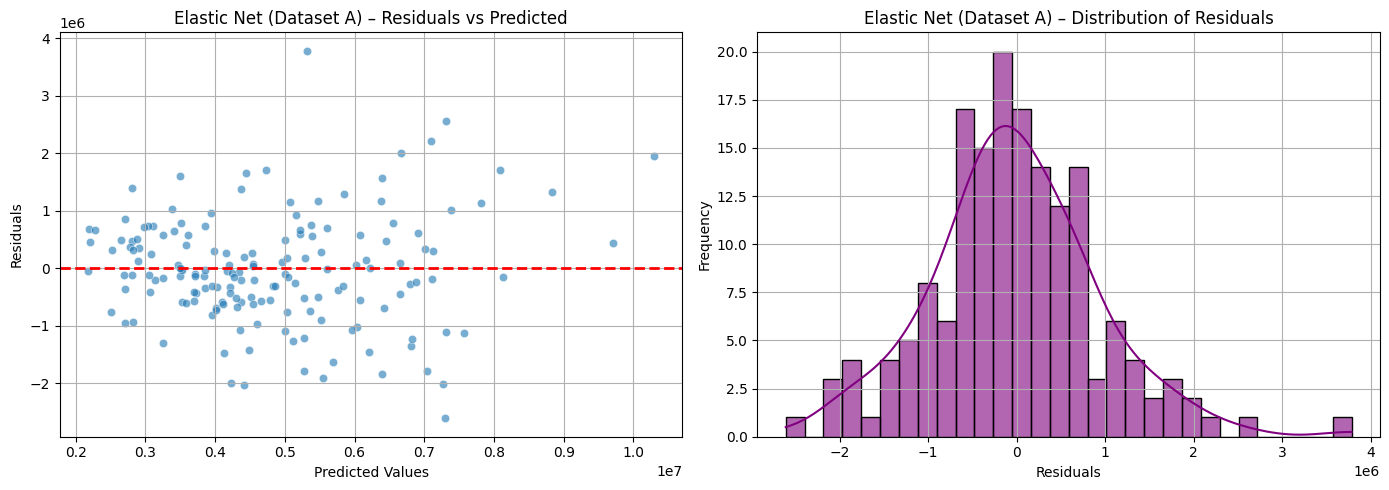

In [110]:
plot_residuals(en_A, X_test_A, y_test, title_prefix="Elastic Net (Dataset A)")

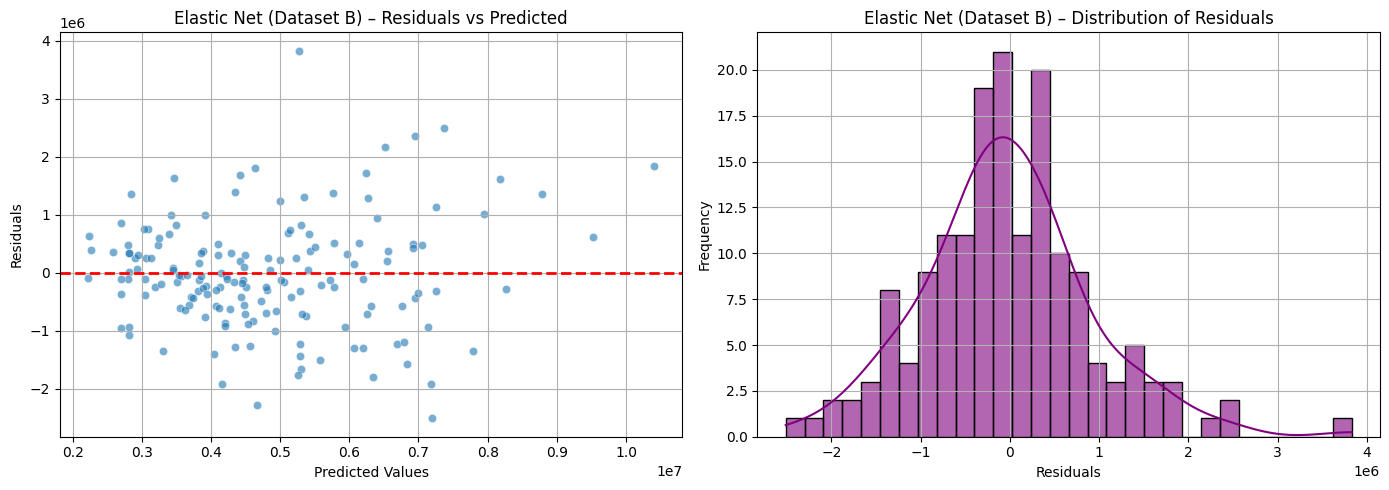

In [111]:
plot_residuals(en_B, X_test_B, y_test, title_prefix="Elastic Net (Dataset B)")

### Analysis of Residual Plots

The residual plots reveal a small but noticeable difference between the two dataset 
representations. Models trained on **Dataset A** (where `furnishingstatus` is kept as a 
single numeric feature) show a smoother and more regular distribution of residuals. The 
errors are spread more evenly around zero, indicating a slightly more stable fit.

In contrast, the residual distributions in **Dataset B** tend to show sharper peaks and 
a less uniform shape across all models. This suggests that one-hot encoding 
`furnishingstatus` does not provide additional useful information to the model and may 
introduce unnecessary noise, since this feature has relatively low predictive power.

Overall, while the numerical metrics for the two datasets are almost identical, the 
residual analysis indicates that **Dataset A leads to slightly more consistent and 
better-behaved prediction errors**.